# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: XX     |  |
| :-------------|:-------------|
| Zahra Ramdane | 6533183 |
| Student naam 2| Student Studienummer 2 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

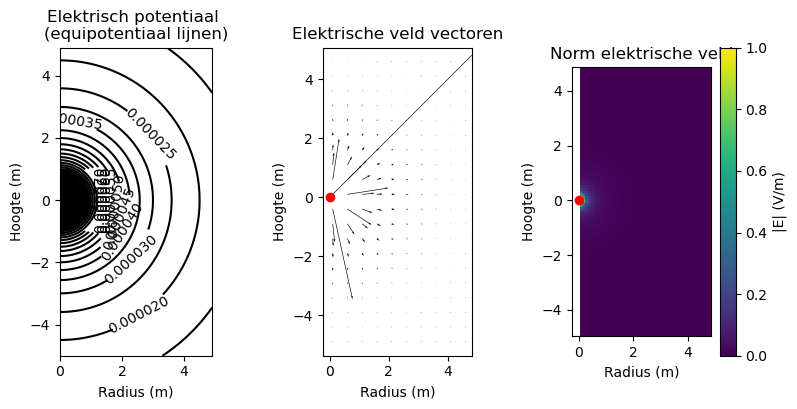

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z = 0 m: 50


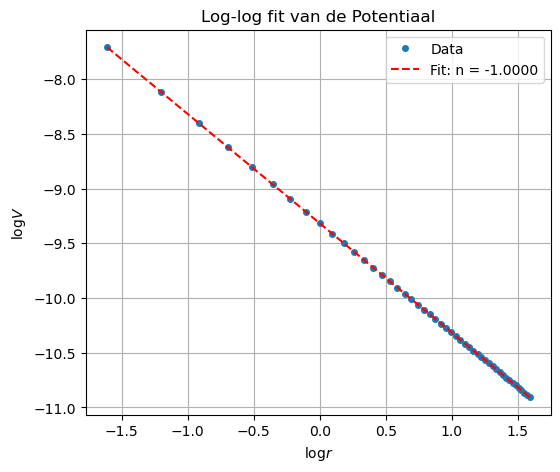

De berekende exponent n voor de potentiaal is: -1.0000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


index_z0 = np.argmin(np.abs(z))
print(f"Index voor z = 0 m: {index_z0}")

# z=0 lijn van het potentiaal
V_line = V[index_z0, :]
r_line = np.abs(r)


mask = r_line > grid_step 
r_fit = r_line[mask]
V_fit = V_line[mask]


log_r = np.log(r_fit)
log_V = np.log(V_fit)

def model(x, a, b):
    return a * x + b

# popt[0] is je exponent a en popt[1] is je constante b
popt, _ = curve_fit(model, log_r, log_V)
exponent = popt[0]
a_fit, b_fit = popt


plt.figure(figsize=(6,5))
plt.plot(log_r, log_V, 'o', markersize=4, label='Data')
plt.plot(log_r, model(log_r, *popt), 'r--', label=f'Fit: n = {a_fit:.4f}')
plt.xlabel("log$r$")
plt.ylabel("log$V$")
plt.title("Log-log fit van de Potentiaal")
plt.legend()
plt.grid(True)
plt.show()

print(f"De berekende exponent n voor de potentiaal is: {a_fit:.4f}")



##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

Index voor z = 0 m: 49


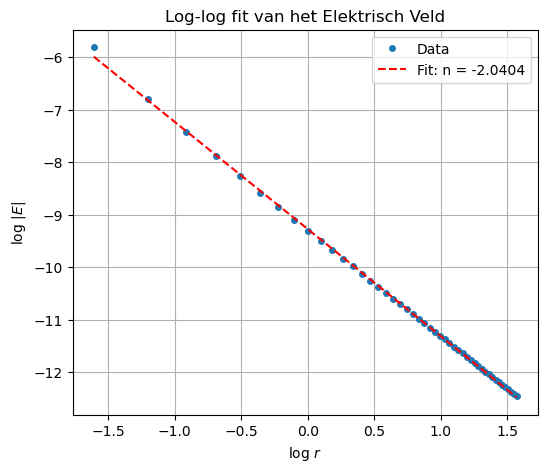

De exponent n voor het elektrische veld is: -2.0404


In [4]:
# Index voor z = 0 m
index_z0 = np.argmin(np.abs(z_for_E))   #z_for_E omdat dat de z-array is die overeenkomt met de E-waarden, en niet de originele z-array die bij V hoort.
print(f"Index voor z = 0 m: {index_z0}")

E_line = normE[index_z0, :]           
r_line = np.abs(r_for_E)  #alleen poistieve waardes kunnen in de log-log plot, dus alleen absolute waarde van r_for_E             

# Singulairietit vermijden
mask = r_line > grid_step
r_fit = r_line[mask]
E_fit = E_line[mask]


log_r = np.log(r_fit)
log_E = np.log(E_fit)

#Fit
def model(x, a, b):
    return a * x + b

popt, _ = curve_fit(model, log_r, log_E) #want E-vled voor puntladingen is radiaal naar buiten gericht. 
a_fit, b_fit = popt

# Plot
plt.figure(figsize=(6,5))
plt.plot(log_r, log_E, 'o', markersize=4, label='Data')
plt.plot(log_r, model(log_r, *popt), 'r--', label=f'Fit: n = {a_fit:.4f}')
plt.xlabel("log $r$")
plt.ylabel("log $|E|$")
plt.title("Log-log fit van het Elektrisch Veld")
plt.legend()
plt.grid(True)
plt.show()

print(f"De exponent n voor het elektrische veld is: {a_fit:.4f}")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

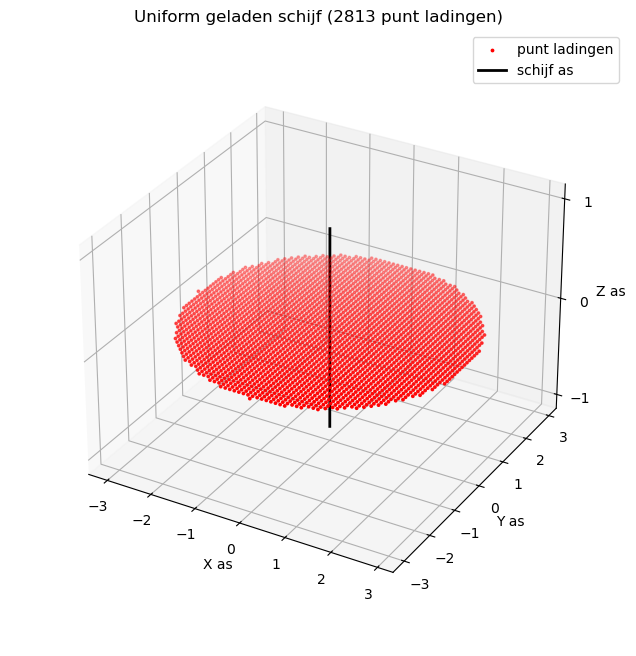

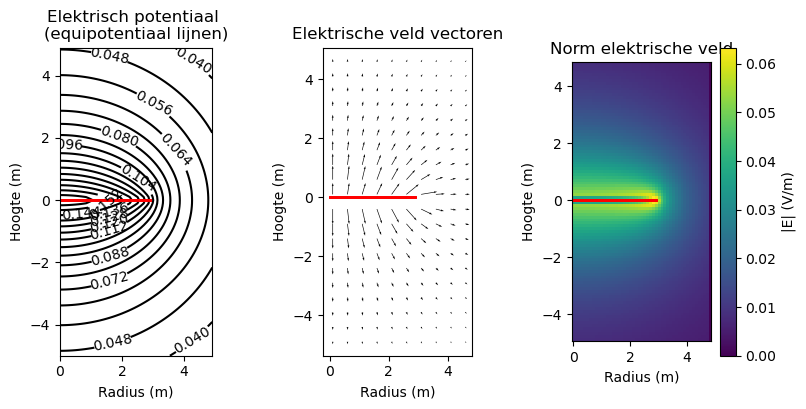

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

- Disk radius: Dit is de straal van de geladen schijf in meters. Als de straal naar 0 gaat, krimpt de schijf tot een punt en gedraagt het systeem zich als een puntlading.

- Gridstep: Dit is de stapgrootte (resolutie) van het rekendomein. Een kleinere gridstep verhoogt de nauwkeurigheid van de simulatie, maar maakt de berekening aanzienlijk trager omdat er meer punten berekend moeten worden.

- Inter_charge_distance: Deze variabele bepaalt de afstand tussen de individuele puntladingen waaruit de schijf is opgebouwd. Een kleinere afstand zorgt voor een meer continue ladingsverdeling (nauwkeuriger), maar verhoogt de rekentijd omdat er meer puntladingen gesommeerd moeten worden.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [44]:
import numpy as np

# 1. Bereken de totale lading en de oppervlakte
total_charge = number_point_charges_on_disk * charge_one_point
area_disk = np.pi * (disk_radius**2)

# 2. Bereken de ladingsdichtheid sigma (C/m^2)
sigma = total_charge / area_disk

# 3. Print het resultaat met de correcte eenheid
print(f"Aantal puntladingen op de schijf: {number_point_charges_on_disk}")
print(f"Totale lading op de schijf: {total_charge:.4e} C")
print(f"De berekende ladingsdichtheid sigma is: {sigma:.4e} C/m**2")


Aantal puntladingen op de schijf: 2813
Totale lading op de schijf: 2.8130e-11 C
De berekende ladingsdichtheid sigma is: 9.9490e-13 C/m**2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

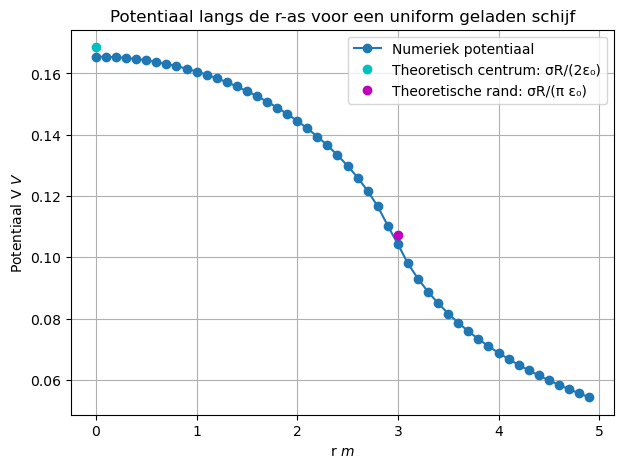

In [8]:
# Index voor z = 0 m
idx_z_zero = np.argmin(np.abs(z))

#Bijbehroende ponetialen door verschillend eaftsand tot (punt)/continue ladingen langs de r-as
V_line = V[idx_z_zero, :]  #rij van index van z=0 en dan gehele kolom nemen. 

# 3. Numerieke potentiaal op r = 0 en dus in het centrum van de schijf
V_0 = V_line[0]

# 4. Numerieke potentiaal op r = R met diskradius is 3 in de r-array is dat dus index die het kleinste absolute verschil geeft met de diskradius van 3, want door gridtep niet elegnate stappen, dus drm niet index te vinden van diskradius door 3 in te vullen, maar op de index die het dichtst bij r=3 ligt.
idx_R = np.argmin(np.abs(r - disk_radius))
V_R = V_line[idx_R]
r_R = r[idx_R] #straal op de r-as die het dichtst bij de diskradius van 3 ligt(drm wrs vershcil gaan zien met V_theory omdat het niet exact r=3 is, maar dichtstbijzijnde waarde in de r-array)

# 5. Theoretische waarden

V_theory_center = sigma * disk_radius / (2 * epsilon0)
V_theory_edge   = sigma * disk_radius / (np.pi * epsilon0)

# Plot
plt.figure(figsize=(7,5))
plt.title("Potentiaal langs de r-as voor een uniform geladen schijf")

plt.plot(r, V_line, "o-", label="Numeriek potentiaal")

plt.plot(0, V_theory_center, "c.", markersize=12, label="Theoretisch centrum: σR/(2ε₀)")

plt.plot(r_R, V_theory_edge, "m.", markersize=12,label="Theoretische rand: σR/(π ε₀)")

plt.xlabel("r $m$")
plt.ylabel("Potentiaal V $V$")
plt.legend()
plt.grid(True)
plt.show()


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


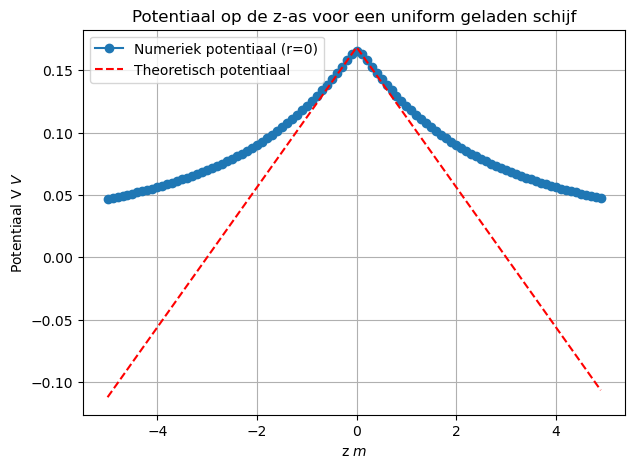

In [9]:
# 1. Numeriek potentiaal op de z-as (r = 0)
z_values = z   #zo genoemd omdat 1 ponetiaal z-array noidg + dan geen aanpassing in deze code als z-waarde wordt aangepast. 
V_z_as = V[:, 0]     #rij bij kolom 0 ieder pontiaal met grid-step dus alle potentiaalwaarden langs de z-as bij r=0, want dat is de eerste kolom van V, dus V[:, 0]

# 2. Theoretisch potentiaal op de z-as
V_theory = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z_values))


plt.figure(figsize=(7,5))
plt.title("Potentiaal op de z-as voor een uniform geladen schijf")

plt.plot(z_values, V_z_as, "o-", label="Numeriek potentiaal (r=0)")
plt.plot(z_values, V_theory, "r--", label="Theoretisch potentiaal")

plt.xlabel("z $m$")
plt.ylabel("Potentiaal V $V$")
plt.legend()
plt.grid(True)


plt.savefig("potentiaal_z_as_schijf2.png", dpi=300)

plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

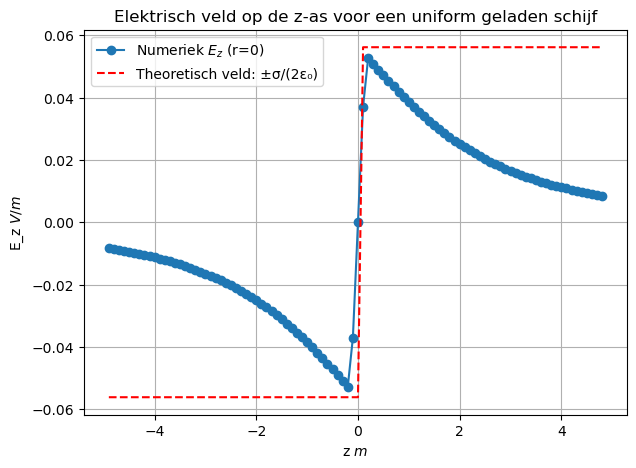

In [10]:
# 1. Numeriek elektrisch veld op de z-as (r = 0)
Ez_zaxis = Ez[:, 0]      #z component van E is dus ookwel geen r-component dus dat moet nul zijn. 
z_values = z_for_E       #2 wardes minder voor E en dus ook voor z tenopzichte van V praktisch gezien, omdat de z-array praktisch gezien groter is is maar door diffenrece methode 2 waarden mist, dus z_for_E gebruiken die bij E hoort, en niet de originele z-array die bij V hoort.

# 2. Theoretisch veld van een oneindig geladen vlak
E_theory = sigma / (2 * epsilon0) #absolute waarde niet vector, 
#want het veld van een oneindig geladen vlak heeft overal dezelfde magnitude, 
# maar de richting verandert afhankelijk van of je boven of onder de schijf bent.
# Dus vector van maken met unit vector geeft richting dat ingesteld wordt met np.where om het veld 
# positief te maken boven de schijf (z > 0) en negatief onder de schijf (z < 0).
E_theory_steps = np.where(z_values > 0, E_theory, -E_theory)

# 3. Plotten
plt.figure(figsize=(7,5))
plt.title("Elektrisch veld op de z-as voor een uniform geladen schijf")

plt.plot(z_values, Ez_zaxis, "o-", label="Numeriek $E_z$ (r=0)")

plt.plot(z_values, E_theory_steps, "r--", label="Theoretisch veld: ±σ/(2ε₀)")


plt.xlabel("z $m$")
plt.ylabel("E_z $V/m$")
plt.legend()
plt.grid(True)

# 4. Opslaan
plt.savefig("elektrisch_veld_z_as_schijf2.png", dpi=300)

plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?

- Vlakbij de schijf, dus rond z=0. Hier is de afstand tot de schijf zo klein ten opzichte van de straal van de schijf dat de schijf oneindig groot lijkt en de rode lijn bijna raakt.

2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

- Afname bij grotere afstand:
Verschil: De rode lijn (plaat) blijft constant, maar de blauwe lijn (schijf) buigt naar nul.
Verklaring: Een oneindige plaat heeft overal een constant veld. Een schijf heeft echter een beperkte hoeveelheid lading; op grote afstand gaat de schijf zich gedragen als een puntlading, waardoor de veldsterkte afneemt naarmate je verder weg gaat.

- De overgang bij z=0: 
Verschil: De rode lijn maakt een directe 'stap', terwijl de blauwe lijn met een schuine lijn door nul gaat.
Verklaring: De theorie gaat uit van een perfecte sprong bij het passeren van de lading. In de numerieke berekening wordt het veld op gegeven stappen berekend. De computer berekent punten aan weerszijden van de schijf en verbindt deze met een lijn. Deze schuine verbinding is een gevolg van de resolutie van het grid, omdat je nooit op z=0 komt. 

- Lagere piekwaarde:
Verschil: De blauwe pieken bereiken net niet de rode stippellijn.
Verklaring: Zelfs heel dichtbij mist de schijf de lading die een oneindige plaat wel heeft aan de verre buitenranden. Hierdoor is het veld van een schijf in de praktijk altijd iets zwakker dan de theoretische waarde voor een oneindig vlak.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

FileNotFoundError: No such file or directory: 'potentiaal_z_as_schijf1.png'

FileNotFoundError: No such file or directory: 'potentiaal_z_as_schijf1.png'

<IPython.core.display.Image object>

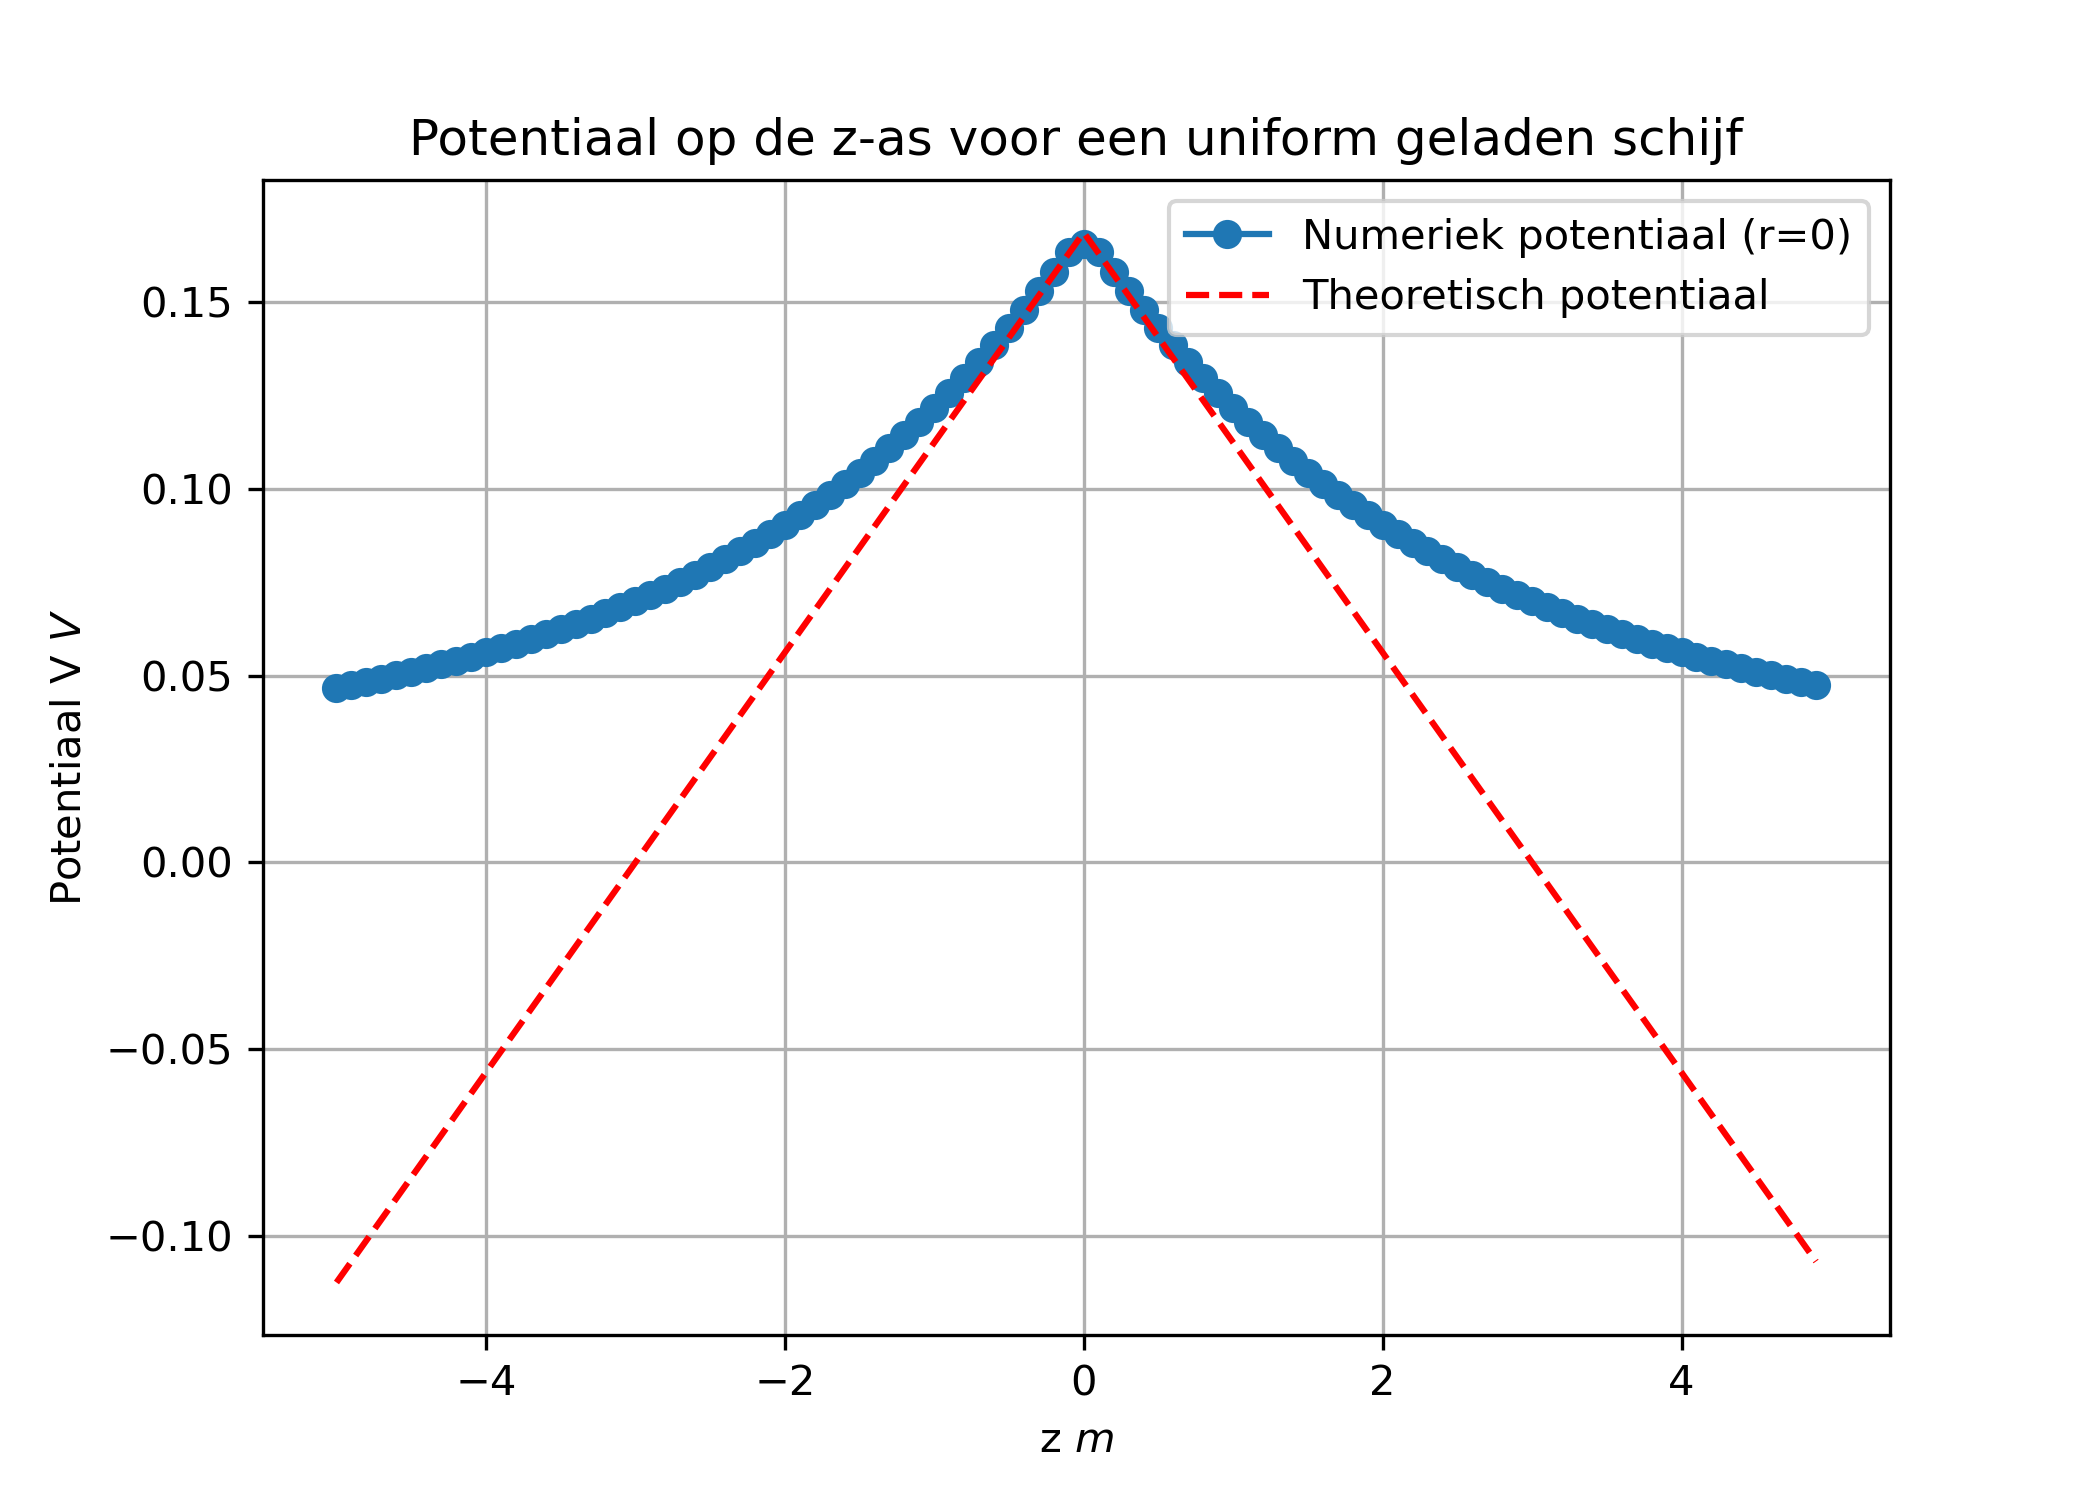

FileNotFoundError: No such file or directory: 'elektrisch_veld_z_as_schijf1.png'

FileNotFoundError: No such file or directory: 'elektrisch_veld_z_as_schijf1.png'

<IPython.core.display.Image object>

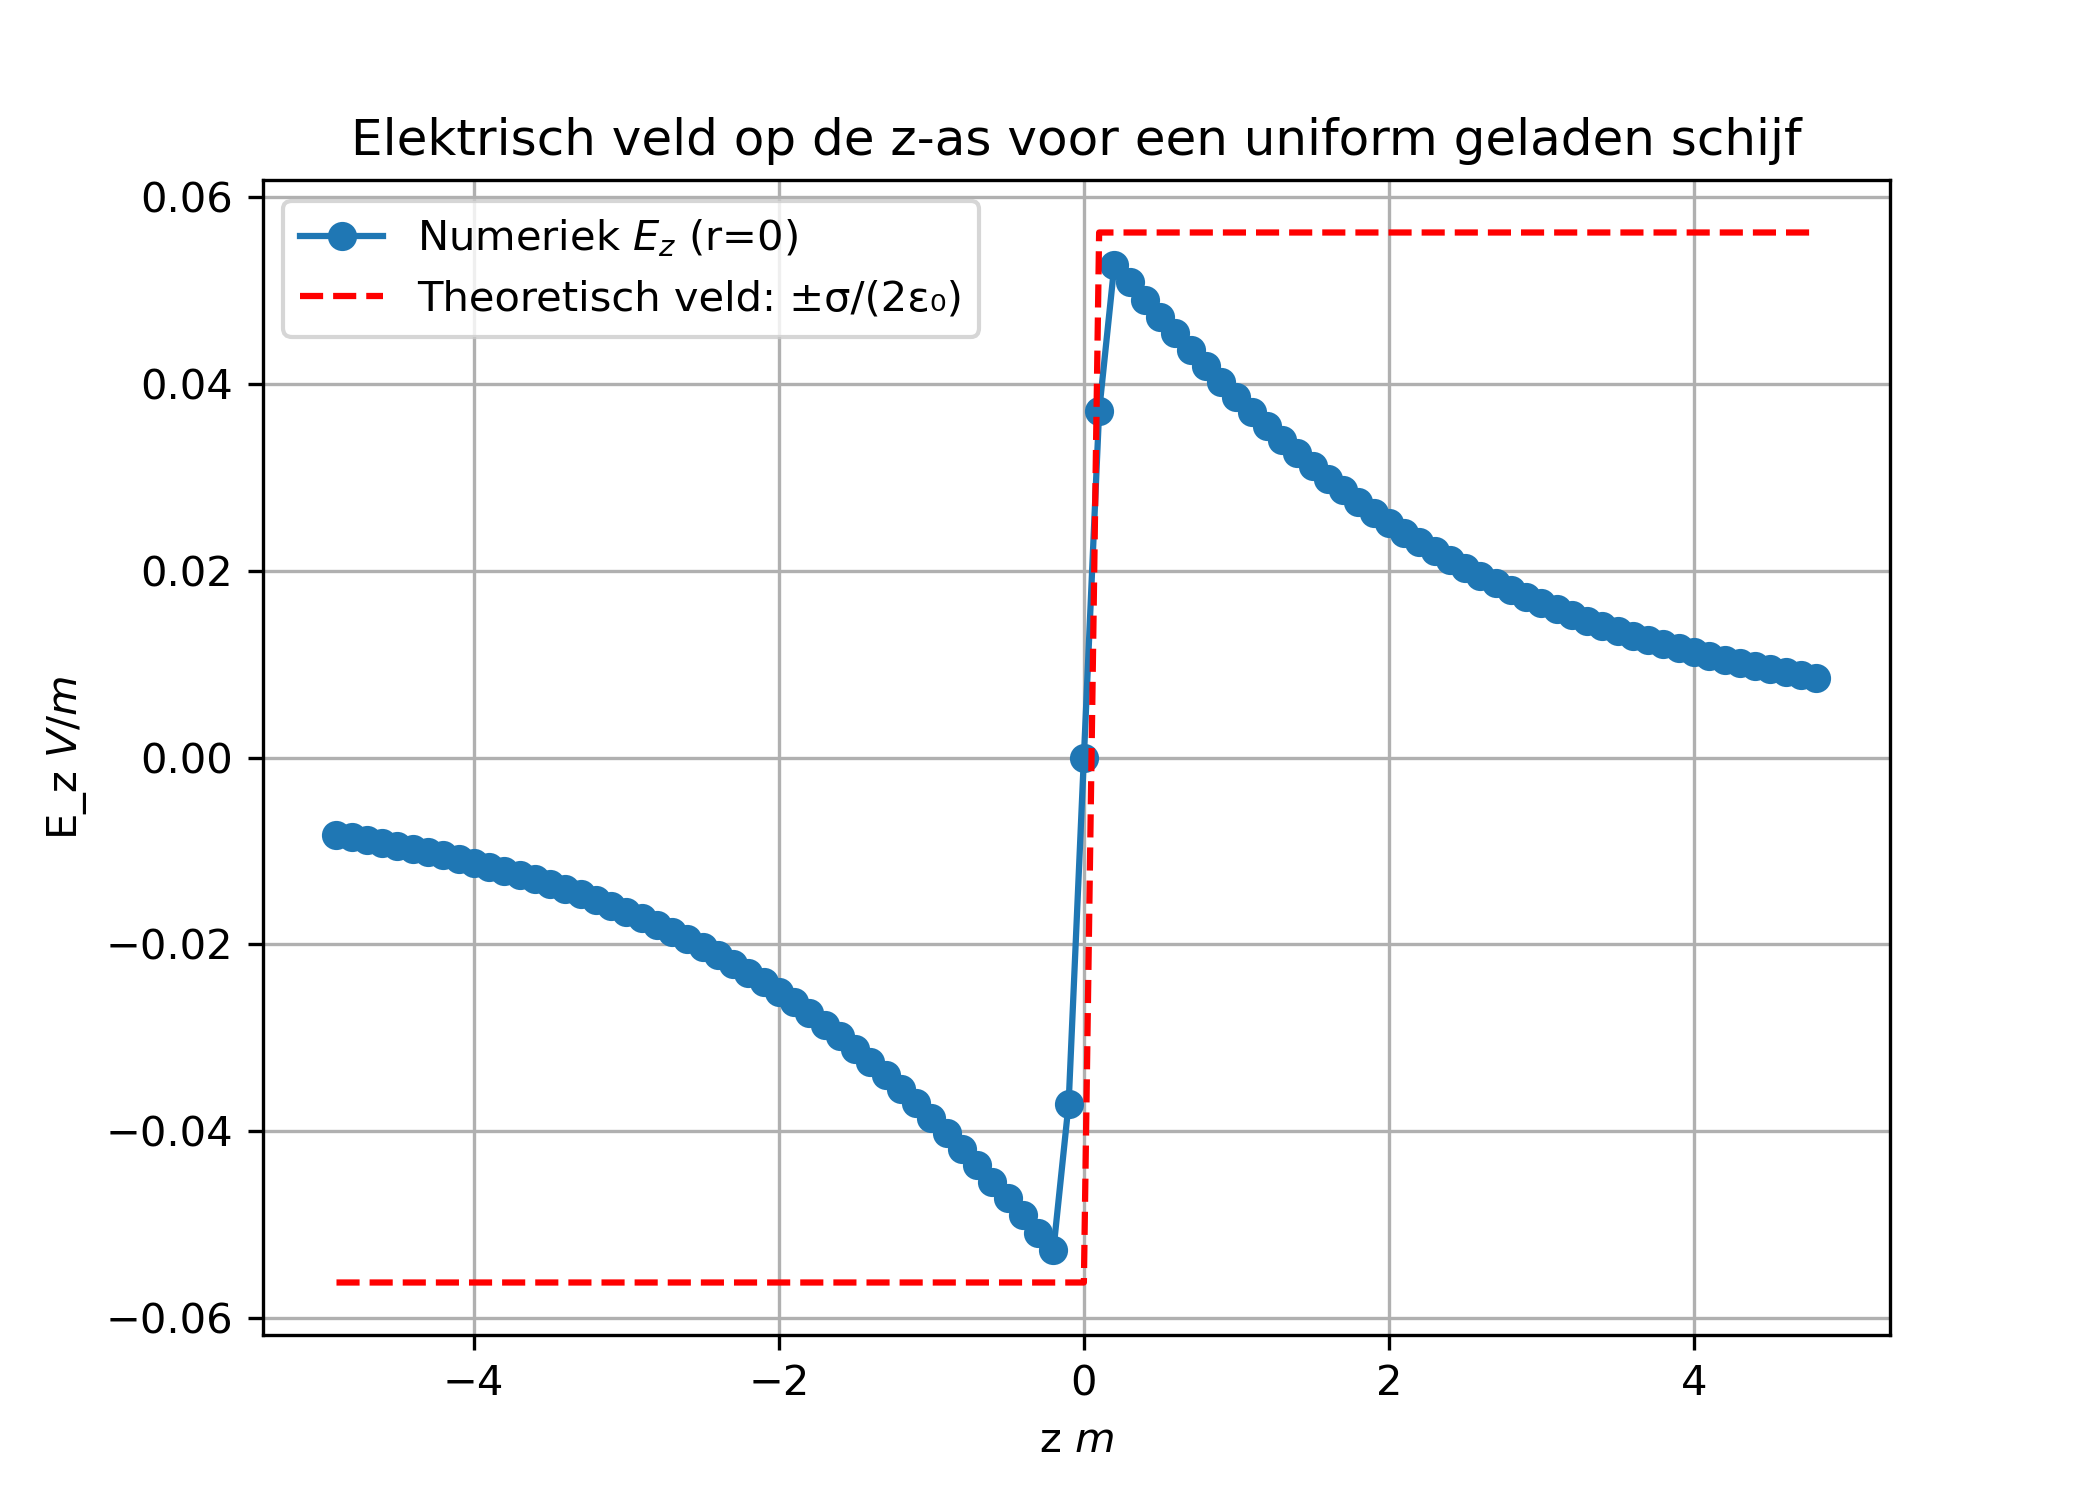

In [11]:
display(Image("potentiaal_z_as_schijf1.png"))
display(Image("potentiaal_z_as_schijf2.png"))
display(Image("elektrisch_veld_z_as_schijf1.png"))
display(Image("elektrisch_veld_z_as_schijf2.png"))


##### Antwoorden 2g


1. Potentiaal op de z-as

- Bij een kleine schijf verandert het potentiaal sneller als je verder van de schijf af gaat.
- De grafiek is duidelijk gebogen en wijkt af van een rechte lijn.
- Bij een grotere schijf wordt het potentiaal veel “vlakder” en gedraagt het zich bijna als een rechte lijn.
- De grotere schijf lijkt daardoor meer op een oneindig groot oppervlak.

2. Elektrisch veld op de z-as

- Bij een kleine schijf verandert het elektrische veld merkbaar met de afstand.
- Het veld wordt zwakker zodra je verder van de schijf af beweegt.
- Bij een grotere schijf blijft het elektrische veld veel langer bijna constant.
- De grafiek ligt dichter bij de theoretische waarde van een oneindig vlak.

3. Uitleg hierachter: 

- Een grotere schijf vult meer van de ruimte, waardoor de randen minder invloed hebben.
- Daardoor lijken de veldlijnen minder “uit te waaieren”.
- Het gedrag van de schijf komt dichter in de buurt van dat van een oneindig vlak.
- Resultaat: zowel het potentiaal als het elektrische veld worden gelijkmatiger en voorspelbaarder.

Conclusie: 

- Hoe groter de schijf, hoe beter de numerieke simulatie overeenkomt met de theorie.
- De schijf met straal 7 m gedraagt zich veel meer als een oneindig geladen oppervlak dan de schijf met straal 3 m.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

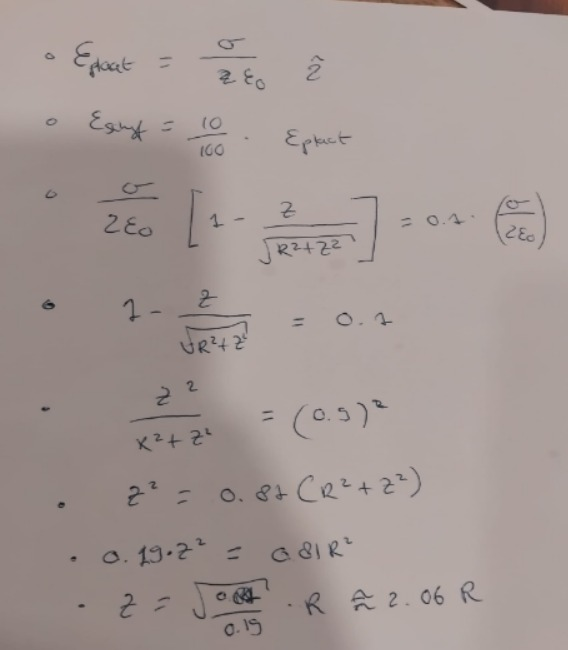

In [12]:
disk_radius = 3  # (m)
grid_step = 0.1
z_coord_DISK = 0
inter_charge_distance = grid_step

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

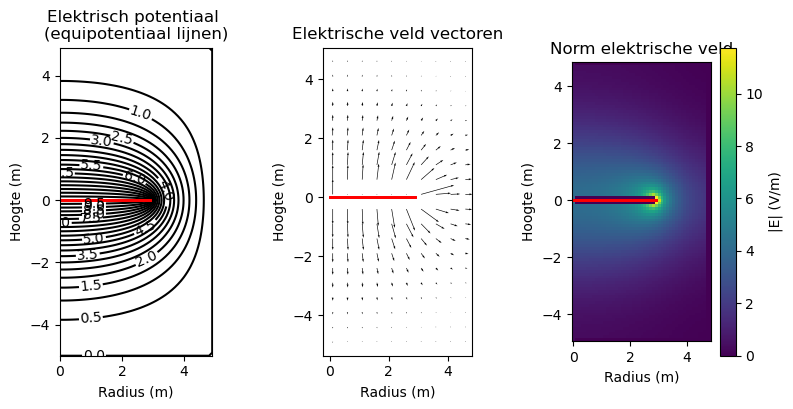

In [13]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

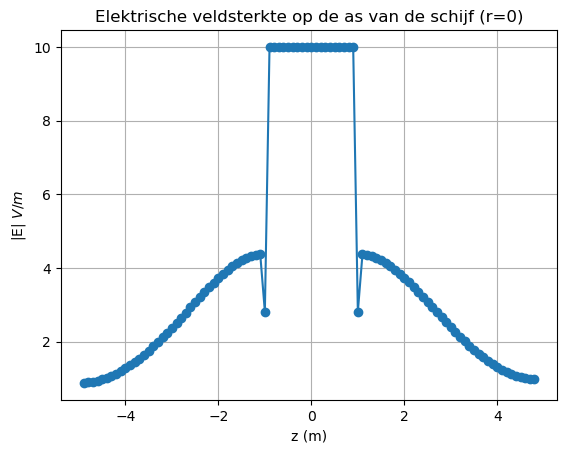

|E| op de as dichtbij het midden van de schijf:
  z = 1.100e+00 m
  |E| = 4.378e+00 V/m


In [ ]:
# Vraag 3a

# 1) Elektrische veldsterkte op de as (r = 0)
idx_r0_E = int(np.argmin(np.abs(r_for_E - 0.0)))   # index die het dichtst bij r=0 ligt
E_axis = normE[:, idx_r0_E]                        # |E|(z) op de as

plt.figure()
plt.title("Elektrische veldsterkte op de as van de schijf (r=0)")
plt.plot(z_for_E, E_axis, "o-")
plt.xlabel("z (m)")
plt.ylabel(r"|E| $V/m$ ")
plt.grid(True)
plt.show()

# 2) |E| heel dicht bij het midden van de schijf
# We willen dicht bij z = z_pos_disk1, maar niet exact erop, want symmetriepunt volgens simulatie leidt tot nul, 
# terwijl het veld daar juist maximaal zou moeten zijn, 
# want methode van Evelden nemen doet klakkeloos e_recht e_links vergelijken, 
# terwijl we hier te maken hebben met discontunuteit omdat z naar nul gaat, 
# dus z=0 moet worden uitgesloten en er moet dus een z_near gevonden worden. 

z0 = z_pos_disk1

#Het dichtstbijzijnde punt met z=0 + uitsluiting van z=0
dz = np.abs(z_for_E - z0)
z0 = z_pos_disk1

# Masker: True voor alle punten die NIET gelijk zijn aan z0
mask = np.abs(z_for_E - z0) > 1e-12

# Array die alleen de waarden van z_for_E en E_axis bevat waar het masker True is (dus z=0 uitgesloten)
z_filtered = z_for_E[mask]
E_filtered = E_axis[mask]

# Dichtsbijzinde punt zoeken op gefilterde array + een naam geven zodat het duidelijk is dat dit punt dicht bij z=0 ligt, maar niet exact z=0 is.
idx = np.argmin(np.abs(z_filtered - z0))

z_near = z_filtered[idx]
E_near = E_filtered[idx]




print(f"|E| op de as dichtbij het midden van de schijf:")
print(f"  z = {z_near:.3e} m")
print(f"  |E| = {E_near:.3e} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b


In [ ]:
#antwoord vraag 3b.1

# Voor een geleider geldt dat de oppervlakteladingsdichtheid gelijk is aan de
# normale component van het elektrische veld net buiten het oppervlak:
#
# sigma = epsilon0 * E_perp
#
# In het midden van de schijf (r = 0) staat het elektrische veld loodrecht op het
# oppervlak, waardoor de normale component gelijk is aan de z-component van het veld.
# De oppervlaktelading in het midden kan daarom benaderd worden met:
#
# sigma(r=0) = epsilon0 * |Ez(r=0, z=0+)|
#
# waarbij Ez(r=0, z=0+) het elektrische veld net boven het oppervlak van de schijf is.

In [ ]:
# Vraag 3b.2:

epsilon0 = 8.854e-12  # F/m

# index voor r=0 op het E-grid
idx_r0_E = int(np.argmin(np.abs(r_for_E - 0.0)))

z0 = z_pos_disk1   

# Masker: True voor alle punten die Niet gelijk zijn aan z0
mask = np.abs(z_for_E - z0) > 1e-12

#Arrays maken met geen z=0 waarde om discontunuteit te vermijden, want z=0 is symmetriepunt volgens simulatie leidt tot nul,
z_filtered = z_for_E[mask]
Ez_filtered = Ez[:, idx_r0_E][mask]

#Dit z punt opzoeken met argmin waar dus geen z=0 uitkomt, maar wel dicht bij z=0 ligt. 
idx_near = np.argmin(np.abs(z_filtered - z0))

#Z-waarde die dan dicht bij z=0 ligt realiseren en bijbehorende Ez-waarde opzoeken van deze waarde
z_near = z_filtered[idx_near]
Ez_near = Ez_filtered[idx_near]

sigma_center = epsilon0 * abs(Ez_near)

print("Benadering oppervlaktelading in het midden van de schijf (r=0):")
print(f"  punt gebruikt: z = {z_near:.3e} m (net buiten het oppervlak)")
print(f"  Ez(r=0,z) = {Ez_near:.3e} V/m")
print(f"  sigma = ε0 |Ez| = {sigma_center:.3e} C/m**2")

Benadering oppervlaktelading in het midden van de schijf (r=0):
  punt gebruikt: z = 1.100e+00 m (net buiten het oppervlak)
  Ez(r=0,z) = 4.378e+00 V/m
  sigma = ε0 |Ez| = 3.876e-11 C/m**2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


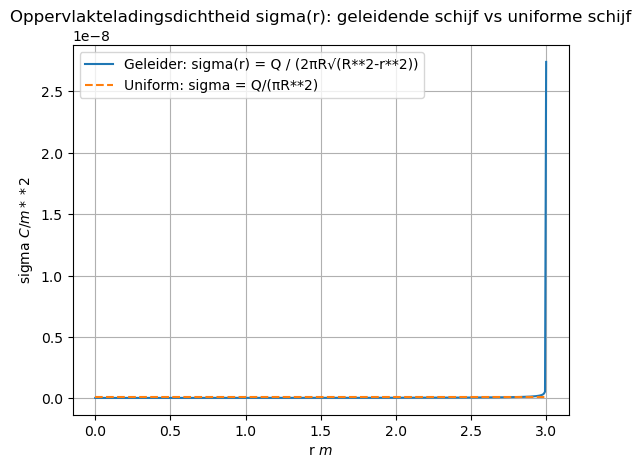

In [ ]:
epsilon0 = 8.854e-12
R = disk_radius

# 1) Benadering van sigma(0) uit Ez net buiten het oppervlak bij r=0

# index van r = 0
idx_r0_E = np.argmin(np.abs(r_for_E - 0))

# z = 0 uitsluiten
z0 = z_pos_disk1
mask = np.abs(z_for_E - z0) > 1e-12

z_filtered = z_for_E[mask]
Ez_filtered = Ez[:, idx_r0_E][mask]

# dichtstbijzijnde punt bij de schijfrand
idx_near = np.argmin(np.abs(z_filtered - z0))

#Index invullen om bijberhoende E-veld waarde te vinden:
z_near = z_filtered[idx_near]
Ez_near = Ez_filtered[idx_near]

sigma_center_cond = epsilon0 * abs(Ez_near)

# 2) Schatting van de totale lading op de schijf 
Q_est = 2 * np.pi * R**2 * sigma_center_cond
sigma_uniform = Q_est / (np.pi * R**2)
r_plot = np.linspace(0, R*(1-1e-6), 400)

# 3 en 4
plt.figure()
plt.title("Oppervlakteladingsdichtheid sigma(r): geleidende schijf vs uniforme schijf")

plt.plot(r_plot, sigma_cond, label="Geleider: sigma(r) = Q / (2πR√(R**2-r**2))")
plt.plot(r_plot, sigma_uniform*np.ones_like(r_plot), "--", label="Uniform: sigma = Q/(πR**2)")
#zodat ik niet hoef te berekenen voor elke r-waarde, maar gewoon een horizontale lijn kan plotten op de waarde van sigma_uniform, want dat is de uniforme ladingsdichtheid die overal gelijk is.
plt.xlabel("r $m$")
plt.ylabel("sigma $C/m**2")
plt.grid(True)
plt.legend()
plt.show()
sigma_cond = Q_est / (2 * np.pi * R * np.sqrt(R**2 - r_plot**2))

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [ ]:
# 1) Maximum elektrische veldsterkte in het domein (op E-grid)
Emax = np.max(normE)

# 2) Locatie van dat maximum voor r en z indexen vinden en dan waardes
idx_flat = np.argmax(normE)
idx_z_max, idx_r_max = np.unravel_index(idx_flat, normE.shape) #matrix van maken zodat ik de bijbehorende r- en z-indexen kan vinden van het maximum veldsterkte.

z_Emax = z_for_E[idx_z_max]
r_Emax = r_for_E[idx_r_max]

# 3) Elektrisch veld in het "midden" van de schijf (op de as, net buiten het oppervlak)
idx_r0_E = int(np.argmin(np.abs(r_for_E - 0.0)))

z0 = z_pos_disk1

mask = np.abs(z_for_E - z0) > 1e-12

z_filtered = z_for_E[mask]
E_filtered = normE[:, idx_r0_E][mask]


idx_near_center = np.argmin(np.abs(z_filtered - z0))

z_center_used = z_filtered[idx_near_center]
E_center = E_filtered[idx_near_center]

ratio = Emax / E_center

# 4) Netjes printen
print("Vraag 3d resultaten (edge effect):")
print(f"1) Maximum |E| in de simulatie: {Emax:.3e} V/m")
print(f"2) Locatie van maximum: r = {r_Emax:.3e} m, z = {z_Emax:.3e} m")
print(f"3) |E| op de as dichtbij het midden: {E_center:.3e} V/m (bij z = {z_center_used:.3e} m)")
print(f"   Verhouding: E_max / E_midden ≈ {ratio:.3f}")
print(f"   Verschil: E_max - E_midden = {(Emax - E_center):.3e} V/m")

Vraag 3d resultaten (edge effect):
1) Maximum |E| in de simulatie: 1.175e+01 V/m
2) Locatie van maximum: r = 3.000e+00 m, z = 1.000e-01 m
3) |E| op de as dichtbij het midden: 4.202e+00 V/m (bij z = 1.000e-01 m)
   Verhouding: E_max / E_midden ≈ 2.797
   Verschil: E_max - E_midden = 7.551e+00 V/m


##### Antwoord 3d.5

*Schrijf hier je argumentatie voor vraag 3d.5.*

In [19]:

# Het lokaal hoge elektrische veld ontstaat door het edge effect.
# Bij een geleider herverdelen de vrije ladingen zich zo dat het potentiaal
# overal op de schijf constant blijft.
#
# Aan de rand van de schijf is de kromming effectief scherper en kunnen
# veldlijnen makkelijker naar buiten buigen. Hierdoor hoopt lading zich op
# bij de rand, wat leidt tot een hogere oppervlakteladingsdichtheid en dus
# een groter normaal elektrisch veld net buiten het oppervlak
# (E_perp = sigma / epsilon0).
#
# In de ideale theorie divergeert sigma(r) zelfs als r -> R, waardoor ook het
# elektrische veld daar zeer groot wordt. In de numerieke simulatie blijft
# deze waarde eindig door de beperkte grid-resolutie.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

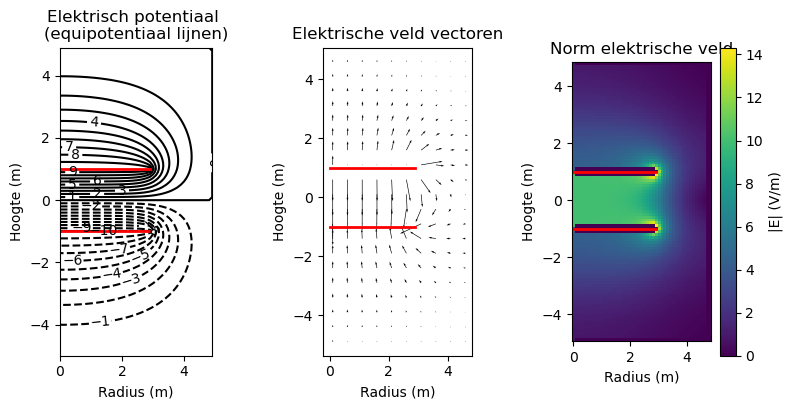

In [20]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


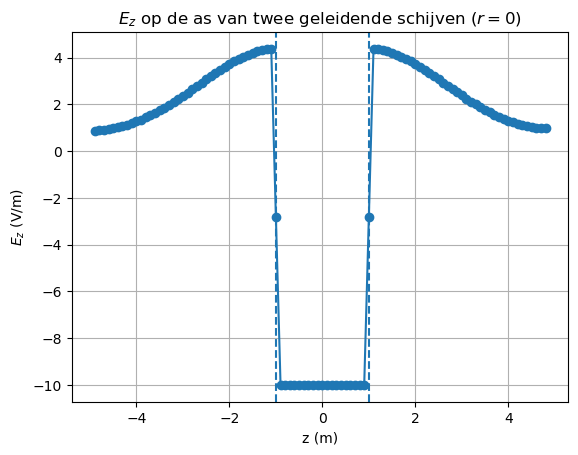

In [ ]:
# Vraag 4a: Plot Ez op de as (r = 0)

# index voor r=0 op het E-grid er dichtbij wnat door step grid niet helmaal op r=0 ligt, maar dichtstbijzijnde waarde in r_for_E die dicht bij 0 ligt.
idx_r0_E = int(np.argmin(np.abs(r_for_E - 0.0)))

Ez_axis = Ez[:, idx_r0_E]  # Ez(z) op de as

plt.figure()
plt.title(r"$E_z$ op de as van twee geleidende schijven ($r=0$)")
plt.plot(z_for_E, Ez_axis, "o-")
plt.axvline(z_pos_disk1, linestyle="--")
plt.axvline(z_pos_disk2, linestyle="--")
plt.xlabel("z (m)")
plt.ylabel(r"$E_z$ (V/m)")
plt.grid(True)
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

*Laat in deze markdown cel je antwoorden op vraag 4b zien.*

In [22]:

# 1) Theoretisch elektrisch veld tussen twee geleidende platen
# Tussen twee oneindig grote, parallelle geleidende platen op potentiaal V1 en V2
# geldt dat er geen lading in de ruimte tussen de platen zit, dus:
# d^2V/dz^2 = 0
# Dit geeft een lineaire oplossing: V(z) = a*z + b
#
# Met randvoorwaarden V(+d/2)=V1 en V(-d/2)=V2 volgt:
# V(z) = (V1 - V2)/d * z + (V1 + V2)/2
#
# Het elektrische veld is E = -grad(V), dus op de as:
# Ez = -dV/dz = -(V1 - V2)/d
#
# Dit betekent dat het elektrische veld tussen de platen constant is.
# Buiten de platen is het veld idealiter ongeveer nul doordat de velden
# van beide platen elkaar daar opheffen.
#
# Regio-indeling langs de z-as:
# - Boven bovenste plaat: E = 0
# - Tussen de platen: Ez = -(V1 - V2)/d (constant)
# - Onder onderste plaat: E = 0
#
# 2) Vergelijking met numerieke simulatie
# In de numerieke resultaten is te zien dat Ez op de as tussen de platen
# ongeveer constant is. Dicht bij de platen en bij de randen treden afwijkingen
# op door rand- (fringing) effecten. Verder weg buiten de platen gaat Ez richting nul.
# Dit komt kwalitatief overeen met de theorie.
#
# 3) Vergelijking met één enkele schijf
# Bij één geleidende schijf op potentiaal V is het veld op de as minder uniform
# en neemt het sneller af met afstand. Met twee schijven op +V en -V ontstaat
# in het midden een veel homogener veld.
# Het voordeel van deze configuratie is dus dat je een betere benadering krijgt
# van een parallelplaatcondensator met een goed gedefinieerd en bijna constant veld.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [58]:

# Vraag 4c: Verwachte sigma, Q en C voor twee geleidende platen


epsilon0 = 8.854e-12   # permittiviteit van vacuüm (F/m)


R = disk_radius
A = np.pi * R**2        # oppervlak van één schijf

# Afstand tussen de platen en spanningsverschil
d = spacing_between_disks
dV = V1 - V2            # ΔV = 10 - (-10) = 20 V



# 1) Verwacht elektrisch veld tussen de platen
#    (parallelplaat-benadering: E = ΔV / d)


E_theory = abs(dV) / d          # grootte van het veld (V/m)

# Ladingsdichtheid op de binnenkant van één plaat
sigma_inner = epsilon0 * E_theory   # (C/m^2)



# 2) Verwachte totale lading op één plaat
#    Q = sigma * A


Q_one_plate = sigma_inner * A          # lading op binnenzijde van één plaat
Q_both_plates_total = 2 * Q_one_plate  # som van beide binnenzijden

# 3) Capaciteit van het systeem
#    C = Q / ΔV  (gebruik Q van één plaat)


C_theory = Q_one_plate / abs(dV)



print("Vraag 4c: Verwachte waarden (parallelplaat-benadering)")
print(f"  Straal R                 = {R:.3f} m")
print(f"  Oppervlak A              = {A:.3e} m^2")
print(f"  Afstand d                = {d:.3f} m")
print(f"  Spanningsverschil ΔV     = {dV:.3f} V")
print(f"  Verwacht veld |E|        = {E_theory:.3e} V/m")
print(f"  Verwachte sigma (binnen) = {sigma_inner:.3e} C/m^2")
print(f"  |Q| op binnenzijde (1 plaat) = {Q_one_plate:.3e} C")
print(f"  Totale |Q| op beide binnenzijden = {Q_both_plates_total:.3e} C")
print(f"  Capaciteit C ≈ |Q|/|ΔV|  = {C_theory:.3e} F")

Vraag 4c: Verwachte waarden (parallelplaat-benadering)
  Straal R                 = 3.000 m
  Oppervlak A              = 2.827e+01 m^2
  Afstand d                = 2.000 m
  Spanningsverschil ΔV     = 20.000 V
  Verwacht veld |E|        = 1.000e+01 V/m
  Verwachte sigma (binnen) = 8.854e-11 C/m^2
  |Q| op binnenzijde (1 plaat) = 2.503e-09 C
  Totale |Q| op beide binnenzijden = 5.007e-09 C
  Capaciteit C ≈ |Q|/|ΔV|  = 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

*Beantwoord in deze markdown cel vraag 4d.*

In [24]:
# Antwoord 4d
#
# 1) Is de oppervlaktelading aan de buitenkant van de schijven nul?
# Nee, niet helemaal. In het ideale geval van oneindig grote parallelle platen zou
# vrijwel alle lading op de binnenkanten zitten en zou er buiten geen veld zijn.
# In deze simulatie zijn de schijven echter eindig, waardoor veldlijnen bij de randen
# naar buiten buigen. Hierdoor komt er ook lading op de buitenkant van de schijven,
# vooral dicht bij de rand.
#
# 2) Wat is het elektrische veld nabij het oppervlak van een geleider?
# Binnen in een geleider is het elektrische veld nul. Net buiten het oppervlak staat
# het elektrische veld loodrecht op het oppervlak en de grootte hangt samen met de
# oppervlaktelading via:
# E_perp = sigma / epsilon0
# of omgekeerd:
# sigma = epsilon0 * E_perp

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [ ]:
#Vraag 4e: 

epsilon0 = 8.854e-12  # F/m

# Op de as: r = 0
idx_r0_E = np.argmin(np.abs(r_for_E - 0.0))


# Z-waarden net onder en net boven de onderste schijf
z_plate_bottom = z_pos_disk2   # z-positie van de onderste schijf

# Voor verwarring voorkomen: de z-waarden die bij de E-array horen, zijn z_for_E, niet de originele z-array die bij V hoort, omdat de E-waarden zijn berekend met een centered finite-difference methode die niet op de allereerste en allerlaatste gridpunten kan rekenen. Daarom moeten we z_for_E gebruiken om de bijbehorende z-waarden te krijgen voor de E-waarden.
z_vals = z_for_E

# Command voor z-waarden net onder en net boven de onderste schijf te vinden: in z-array
mask_below = z_vals < z_plate_bottom    # punten met z < z_plaat
mask_above = z_vals > z_plate_bottom    # punten met z > z_plaat

z_below_candidates = z_vals[mask_below]
z_above_candidates = z_vals[mask_above]

#Voor alle z-waarde met r=0 elektrisch velden:

Ez_on_axis = Ez[:, idx_r0_E]   

Ez_below_candidates = Ez_on_axis[mask_below]
Ez_above_candidates = Ez_on_axis[mask_above]

# Z-component van E net onder de onderste schijf
idx_below = np.argmax(z_below_candidates)   # grootste z die nog < z_plaat is
z_below = z_below_candidates[idx_below]
Ez_below = Ez_below_candidates[idx_below] # en dus bijbehorende Ez-waarde 
#dichtbij het oppervlak van de onderste schijf, maar net onder het oppervlak, 
#want z_below is de grootste z-waarde die nog kleiner is dan z_plaat, dus dat is net onder het oppervlak.

# z-component van E net boven de onderste schijf
idx_above = np.argmin(z_above_candidates)   # kleinste z die > z_plaat is
z_above = z_above_candidates[idx_above]
Ez_above = Ez_above_candidates[idx_above] # hetzelfde geldt hier, 
#maar dan net boven het oppervlak van de onderste schijf, 
#want z_above is de kleinste z-waarde die nog groter is dan z_plaat, 
# dus dat is net boven het oppervlak.


#Ladingsdichtheid aan de onderkant van de onderste plaat

sigma_bottom = epsilon0 * Ez_below

#Ladingsdichtheid aan de bovenkant van de onderste plaat
sigma_top = epsilon0 * Ez_above


print("Vraag 4e: Numeriek berekende ladingsdichtheid op de onderste plaat")
print(f"1) Ez op de as net onder de onderste schijf:  Ez_below = {Ez_below:.3e} V/m (bij z = {z_below:.3e} m)")
print(f"2) Sigma onderkant onderste plaat:           sigma_bottom = {sigma_bottom:.3e} C/m**2")
print(f"3) Ez op de as net boven de onderste schijf: Ez_above = {Ez_above:.3e} V/m (bij z = {z_above:.3e} m)")
print(f"4) Sigma bovenkant onderste plaat:           sigma_top = {sigma_top:.3e} C/m**2")

Vraag 4e: Numeriek berekende ladingsdichtheid op de onderste plaat
1) Ez op de as net onder de onderste schijf:  Ez_below = -2.810e+00 V/m (bij z = -1.000e+00 m)
2) Sigma onderkant onderste plaat:           sigma_bottom = -2.488e-11 C/m**2
3) Ez op de as net boven de onderste schijf: Ez_above = -1.000e+01 V/m (bij z = -9.000e-01 m)
4) Sigma bovenkant onderste plaat:           sigma_top = -8.858e-11 C/m**2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

*Beantwoord vraag 4f in deze cel.*

In [26]:
# Antwoord 4f
#
# 1) Conclusie over de daadwerkelijke lading op een schijf t.o.v. vraag 4c
# In 4c heb ik de parallelplaat-benadering gebruikt: alsof alle lading alleen op de
# binnenkanten zit en het veld buiten nul is. Uit 4d en 4e blijkt dat dit bij eindige
# schijven niet perfect klopt: door rand/“fringing” effecten is Ez buiten de platen niet
# precies nul en krijg je dus ook ladingsdichtheid op de buitenkanten. De echte lading
# op een schijf is dus verdeeld over binnenkant én buitenkant (en is niet exact gelijk
# aan de simpele Q = sigma*A uit 4c als je alleen de binnenkant meeneemt).
#
# 2) Invloed op de capaciteit uit 4c
# Omdat in de echte situatie niet alle veldlijnen netjes tussen de platen blijven
# (een deel “lekt” naar buiten), wijkt de echte capaciteit af van de ideale
# parallelplaatwaarde. In het algemeen zorgt extra fringing ervoor dat de effectieve
# capaciteit vaak iets groter kan worden dan de simpele C = epsilon0*A/d, omdat er
# extra elektrische veldlijnen (en dus extra opgeslagen energie/lading) buiten het
# ideale gebied bijdragen.
#
# 3) Wat verandert er als de afstand tussen de schijven kleiner wordt?
# Als d kleiner wordt, dan wordt het veld tussen de platen groter en homogener in het
# midden (Ez ~ -(V1 - V2)/d wordt in grootte groter). Ook worden rand-effecten relatief
# minder belangrijk: meer veldlijnen lopen recht tussen de platen i.p.v. naar buiten.
# Hierdoor lijkt de configuratie meer op een ideale parallelplaatcondensator en neemt
# de capaciteit toe (ongeveer  1/d).

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [ ]:
#vraag 2
#Formule van de capaciteit van een vlakke plaat condensator. 

import math

EPS0 = 8.8541878128e-12  # F/m

def C_vlakke_plaat(A: float, d: float, eps_r: float = 1.0) -> float:
    """
    Capaciteit vlakke plaatcondensator.
    Parameters:
      A     : plaatoppervlak [m^2]
      d     : plaatafstand [m]
      eps_r : relatieve permittiviteit [-]
    Returns:
      C [F]
    """
    if A <= 0:
        raise ValueError("A moet > 0 zijn.")
    if d <= 0:
        raise ValueError("d moet > 0 zijn.")
    if eps_r <= 0:
        raise ValueError("eps_r moet > 0 zijn.")
    eps = EPS0 * eps_r
    return eps * A / d

EPS0 = 8.8541878128e-12  # F/m

#vraag 4
#formule van vraag 3. cilindercondensator met kleine afstand aaname

def C_cilinder_exact(a: float, b: float, L: float, eps_r: float = 1.0) -> float:
    """
    Capaciteit van een coaxiale cilindercondensator (exact).
    Parameters:
      a     : binnenstraal [m]
      b     : buitenstraal [m] (b > a)
      L     : lengte [m]
      eps_r : relatieve permittiviteit [-]
    Returns:
      C [F]
    """
    if a <= 0 or b <= 0 or L <= 0:
        raise ValueError("a, b en L moeten > 0 zijn.")
    if b <= a:
        raise ValueError("b moet groter zijn dan a.")
    if eps_r <= 0:
        raise ValueError("eps_r moet > 0 zijn.")
    eps = EPS0 * eps_r
    return 2 * math.pi * eps * L / math.log(b / a)


def C_cilinder_kleine_spleet(a: float, t: float, L: float, eps_r: float = 1.0) -> float:
    """
    Capaciteit van een coaxiale cilindercondensator met kleine spleet t = b-a (t << a).
    Parameters:
      a     : binnenstraal [m]
      t     : spleetdikte [m] (= b - a)
      L     : lengte [m]
      eps_r : relatieve permittiviteit [-]
    Returns:
      C [F]
    """
    if a <= 0 or t <= 0 or L <= 0:
        raise ValueError("a, t en L moeten > 0 zijn.")
    if eps_r <= 0:
        raise ValueError("eps_r moet > 0 zijn.")
    eps = EPS0 * eps_r
    return 2 * math.pi * eps * L * a / t

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [ ]:
import math

#Constante
EPS0 = 8.8541878128e-12  # F/m


#Functies

def C_vlakke_plaat(A, d, eps_r=1.0):
    """Capaciteit van een vlakke plaat condensator."""
    return EPS0 * eps_r * A / d


def C_cilinder(a, b, L, eps_r=1.0):
    """Capaciteit van een coaxiale cilindercondensator (exacte formule)."""
    return 2 * math.pi * EPS0 * eps_r * L / math.log(b / a)


def print_capacitance(label, C):
    """Print capaciteit netjes in pF of nF."""
    if C < 1e-9:
        print(f"{label}: {C*1e12:.2f} pF")
    else:
        print(f"{label}: {C*1e9:.2f} nF")



#Gegeven waarden

#Vlakke plaat (10 cm x 10 cm, d = 1 mm)
A = 0.10 * 0.10        # m^2
d = 1e-3               # m

#Cilinder
a = 4.5e-3             # binnenstraal (9 mm diameter)
b = 5.0e-3             # buitenstraal (10 mm diameter)
L = 0.10               # 10 cm

#Relatieve permittiviteit
eps_lucht = 1.0
eps_water = 80.0
eps_pvc = 3.2



# Vraag 1 en 2

print("Vraag 1: Capaciteit met lucht")
C1 = C_vlakke_plaat(A, d, eps_lucht)
C2 = C_cilinder(a, b, L, eps_lucht)

print_capacitance("Vlakke plaat", C1)
print_capacitance("Cilinder", C2)
print()



# Vraag 3: Afstand verdubbeld

print("Vraag 3: Afstand verdubbeld")

# Vlakke plaat: d verdubbelt
C1_double_d = C_vlakke_plaat(A, 2*d, eps_lucht)

# Cilinder: spleet verdubbelt (b wordt groter)
t = b - a
b_new = a + 2*t
C2_double_d = C_cilinder(a, b_new, L, eps_lucht)

print_capacitance("Vlakke plaat (d verdubbeld)", C1_double_d)
print_capacitance("Cilinder (spleet verdubbeld)", C2_double_d)
print()



# Vraag 4: Gevuld met water

print("Vraag 4: Gevuld met water")

C1_water = C_vlakke_plaat(A, d, eps_water)
C2_water = C_cilinder(a, b, L, eps_water)

print_capacitance("Vlakke plaat (water)", C1_water)
print_capacitance("Cilinder (water)", C2_water)
print()



# Vraag 5: Gevuld met PVC

print("Vraag 5: Gevuld met PVC")

C1_pvc = C_vlakke_plaat(A, d, eps_pvc)
C2_pvc = C_cilinder(a, b, L, eps_pvc)

print_capacitance("Vlakke plaat (PVC)", C1_pvc)
print_capacitance("Cilinder (PVC)", C2_pvc)

#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [ ]:
import math

EPS0 = 8.8541878128e-12  # F/m

def C_vlakke_plaat(A, d, eps_r=1.0):
    return EPS0 * eps_r * A / d

def C_cilinder(a, b, L, eps_r=1.0):
    return 2 * math.pi * EPS0 * eps_r * L / math.log(b / a)

def print_length(label, L_m):
    if L_m >= 1000:
        print(f"{label}: {L_m/1000:.3f} km")
    else:
        print(f"{label}: {L_m:.3f} m")


# Vraag 5c


C_target = 1e-6  # 1 microFarad

# Aanname: lucht als medium (eps_r = 1.0), tenzij anders gegeven
eps_r = 1.0

print("Vraag 5c - Resultaten (aannames: eps_r = 1.0, lucht)\n")

# 1) Cilindercondensator: binnendiameter 5 mm, buitendiameter 6 mm
a = 2.5e-3   # m (binnenstraal)
b = 3.0e-3   # m (buitenstraal)

# Omgeschreven formule:
# C = (2π ε L) / ln(b/a)  ->  L = C * ln(b/a) / (2π ε)
eps = EPS0 * eps_r
L_cyl = C_target * math.log(b / a) / (2 * math.pi * eps)

print("1) Cilinder (5 mm -> 6 mm) voor 1 µF")
print_length("Benodigde lengte", L_cyl)
print()

# 2) Vlakke plaat: platen 6 mm breed, afstand 0.5 mm, zoek lengte
w = 6e-3      # m (breedte)
d = 0.5e-3    # m (plaatafstand)

# A = w * lengte
# C = ε A / d = ε (w*L) / d  ->  L = C d / (ε w)
L_plate = C_target * d / (eps * w)

print("2) Vlakke plaat (breedte 6 mm, afstand 0.5 mm) voor 1 µF")
print_length("Benodigde lengte", L_plate)

#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

*Beantwoord hier de vraag 5d.*

In [ ]:
# 1) Zijn de antwoorden uit vraag 5c realistisch?
#
# Nee, deze zijn niet realistisch voor echte condensatoren.
# Ik heb in vraag 5c aangenomen dat het medium tussen de platen lucht is (eps_r = 1).
# Daardoor is de permittiviteit erg klein en moet het oppervlak of de lengte
# extreem groot worden om 1 microFarad te halen.
#
# Dit verklaart waarom ik lengtes van meters of zelfs kilometers kreeg.
# De berekening klopt wiskundig, maar de aannames zijn niet praktisch.


# 2) Hoe lossen echte hoge-capaciteit condensatoren dit op?
#
# Uit de formule C = eps * A / d zie je dat:
# - d zo klein mogelijk moet zijn
# - A zo groot mogelijk moet zijn
# - eps zo groot mogelijk moet zijn





#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [ ]:
import math

# Constante
EPS0 = 8.8541878128e-12  # F/m

# Functie uit vraag 5.1
def C_vlakke_plaat(A, d, eps_r=1.0):
    return EPS0 * eps_r * A / d


# Gegeven / aannames

v_kmh = 70               # km/h
V = 10_000               # V (10 kV)
d = 1e-3                 # m (1 mm plaatafstand)
eps_r_water = 80         # water (ruwe aanname)

# Massa-schatting treintje:
# 6 personen + karretje zelf
personen = 6
m_persoon = 75           # kg per persoon (schatting)
m_kar = 250              # kg karretje (schatting)
m_totaal = personen * m_persoon + m_kar



#Energie van treintje na afschieten (kinetische energie)
v = v_kmh * 1000 / 3600                      # m/s
E = 0.5 * m_totaal * v**2                    # Joule

#Benodigde totale capaciteit bij 10 kV
#E = 1/2 C V^2  ->  C = 2E / V^2

C = (2 * E) / (V**2)                         # Farad


#Oppervlak vlakke-plaat condensator (gevuld met water)
#C = eps0*epsr*A/d  ->  A = C*d/(eps0*epsr)

A = (C * d) / (EPS0 * eps_r_water)           # m^2

#printen
print("=== Vraag 5e: Condensator in een achtbaan ===")
print(f"1) Massa (schatting): {m_totaal:.0f} kg  (={personen}×{m_persoon} kg + {m_kar} kg)")
print(f"   Snelheid: {v_kmh} km/h = {v:.2f} m/s")
print(f"2) Kinetische energie: {E:,.0f} J  (~{E/1000:.1f} kJ)")
print(f"3) Benodigde capaciteit bij {V/1000:.0f} kV: {C:.6f} F  (= {C*1000:.3f} mF)")
print(f"4) Benodigd plaatoppervlak (water, d=1 mm): {A:,.0f} m^2")
print("   (ter vergelijking: dat is ongeveer een vierkant van "
      f"{math.sqrt(A):.1f} m × {math.sqrt(A):.1f} m)")
print()


# Dit is meestal niet realistisch als "één simpele vlakke plaatcondensator":
# - Het benodigde oppervlak wordt groot (duizenden m^2) zelfs met water (eps_r ~80).
# Hoe kan het wél in klein volume?
# - Gebruik een condensatorbank van veel cellen (veel condensatoren parallel/serie).
# - Gebruik supercaps / (elektrolytische) condensatoren met:
#   * extreem dun diëlektricum (heel klein d)
#   * enorm effectief oppervlak (opgerolde folie, geëtst oppervlak)
# - Of gebruik een ander opslagsysteem (bv. vliegwiel/accu) en een buffer-omvormer.

##### Antwoorden 5e

*Edit deze markdown cel met jouw idee hoe de capaciteit toch zo hoog kan zijn.*

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt


# Constante + functies (vraag 5.1)

EPS0 = 8.8541878128e-12  # F/m

def C_vlakke_plaat(A, d, eps_r=1.0):
    return EPS0 * eps_r * A / d

def C_cilinder(a, b, L, eps_r=1.0):
    return 2 * math.pi * EPS0 * eps_r * L / math.log(b / a)


#5.1: Vlakke plaat, d van 0.5 mm tot 5 mm

A = 0.10 * 0.10          # m^2 (10 cm x 10 cm)
eps_r = 1.0              # lucht

d_vals = np.linspace(0.5e-3, 5e-3, 200)          # m
C_plate = C_vlakke_plaat(A, d_vals, eps_r)       # F

plt.figure()
plt.plot(d_vals * 1e3, C_plate * 1e12)           # mm vs pF
plt.xlabel("Plaatafstand d (mm)")
plt.ylabel("Capaciteit C (pF)")
plt.title("Vlakke plaatcondensator: C als functie van d (10 cm × 10 cm, lucht)")
plt.grid(True)
plt.show()


# Vraag 5.2: Cilindercondensator, binnencilinder in 10 s eruit
# Aanname: alleen het overlappende deel telt mee:


L0 = 0.10                # m (10 cm lang)
a = 4.5e-3               # m (9 mm binnendiameter -> straal)
b = 5.0e-3               # m (10 mm buitendiameter -> straal)
T = 10.0                 # s

t_vals = np.linspace(0.0, T, 300)                # s
L_eff = L0 * (1.0 - t_vals / T)                  # m, lineair naar 0
C_cyl = np.array([C_cilinder(a, b, L, eps_r) for L in L_eff])  # F

plt.figure()
plt.plot(t_vals, C_cyl * 1e12)                   # s vs pF
plt.xlabel("Tijd t (s)")
plt.ylabel("Capaciteit C (pF)")
plt.title("Cilindercondensator: C tijdens uittrekken binnencilinder (lucht)")
plt.grid(True)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6 Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

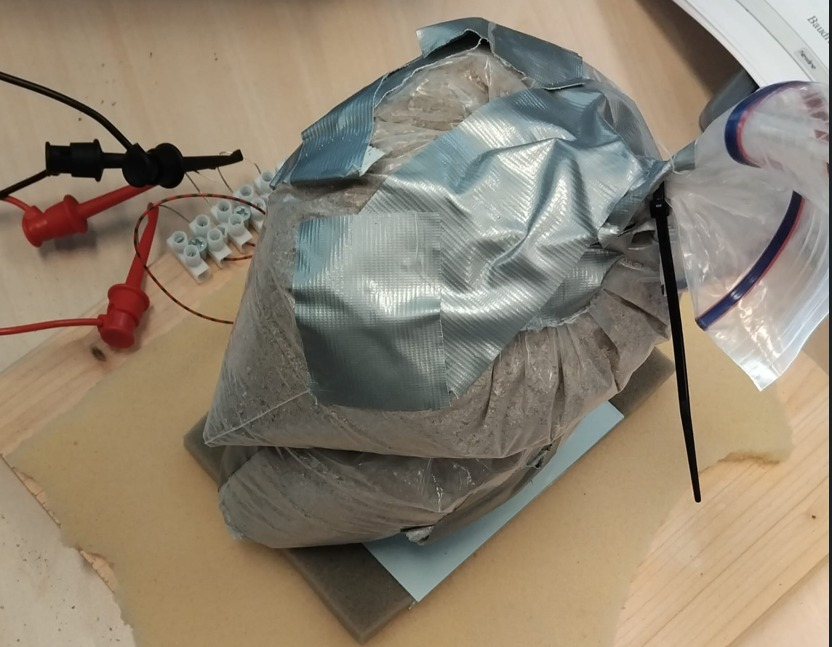
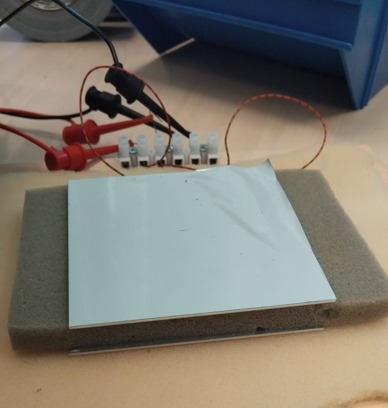

### Data van ontweropdracht 2: 

In [34]:
#Ontwerpgrafiek:
 #Veerconstante bepaaldt voor in de ontwerpgrafiek: 
#uitgaande van een lineaire verband tussen stugheid van de spons en de kracht die nodig is om deze in te duwen. 

import numpy as np
import matplotlib.pyplot as plt

g = 9.81

# Afstanden in meter
afstand_0 = 1.2 / 100
afstand_1 = 1.1 / 100
afstand_2 = 1.0 / 100
afstand_3 = 0.9 / 100

# Massa's in kg
massa_0 = 0
massa_1 = 0.965 + 0.964 + 0.574
massa_2 = 0.965 + 0.964 + 0.574 + 0.4892
massa_3 = 0.965 + 0.964 + 0.574 + 0.9508 + 0.4892 + 0.4827 + 0.9738

massa = np.array([massa_1, massa_2, massa_3])
afstand = np.array([afstand_1, afstand_2, afstand_3])

# Indeuking
delta_x = afstand_0 - afstand

# Kracht
F = massa * g

# Veerconstante per meting
k = F / delta_x

# Gemiddelde veerconstante
k_gemiddeld = np.mean(k)

print("Veerconstante per meting (N/m):", k)
print("Gemiddelde veerconstante (N/m):", k_gemiddeld)
print("de gevonden waarde is veel hoger dan dat je zou verwachten, aangezien een normale huispons een veerconstante heeft tussen de 300 en 500 N/m. Deze hoge waarde kan worden verklaard doordat we relatief kleine massa's gebruiken en het aan het begin moeilijker is om de spons in te duwen, waardoor de gemeten veerconstante hoger uitvalt, maar ook omdat de spons mogelijk niet lineair is en stugger wordt naarmate deze verder wordt ingedrukt.")


epsilon_0 = 8.854187817e-12
epsilon_r = 1.5
oppervlakte = 0.00992
afstand_0 = 1.2 / 100  # 1.2 cm → meter

k = k_gemiddeld
g = 9.81

def capaciteit_plaatcondensator(oppervlakte, afstand, epsilon_r):
    return epsilon_0 * epsilon_r * oppervlakte / afstand

# Massa's van 0 tot 6 kg
massa = np.linspace(0, 6, 100)

# Bereken indeuking
delta_x_voorspelling = (massa * g) / k

# Nieuwe afstand
afstand = afstand_0 - delta_x_voorspelling

# Voorkom negatieve afstanden
afstand[afstand <= 0] = 1e-6

# Bereken capaciteit (in Farad)
Capciteit_voorspelling = capaciteit_plaatcondensator(oppervlakte, afstand, epsilon_r)

# Omzetten naar picoFarad
Capaciteit_voorspellingpF = Capciteit_voorspelling * 1e12

# # Plot indeuking tegen capaciteit in pF
# plt.plot(delta_x_voorspelling, Capaciteit_voorspellingpF)
# plt.xlabel("Indeuking $m$")
# plt.ylabel("Capaciteit $pF$")
# plt.title("Indeuking vs Capaciteit")
# plt.show()

Veerconstante per meting (N/m): [24554.43  14676.741 17656.365]
Gemiddelde veerconstante (N/m): 18962.512000000006
de gevonden waarde is veel hoger dan dat je zou verwachten, aangezien een normale huispons een veerconstante heeft tussen de 300 en 500 N/m. Deze hoge waarde kan worden verklaard doordat we relatief kleine massa's gebruiken en het aan het begin moeilijker is om de spons in te duwen, waardoor de gemeten veerconstante hoger uitvalt, maar ook omdat de spons mogelijk niet lineair is en stugger wordt naarmate deze verder wordt ingedrukt.


In [35]:
 #Punten van de gemeten waarden: 

epsilon_0 = 8.854187817e-12
epsilon_r_spons = 1.5
oppervlakte = 0.01
afstand_0 = 1.2 / 100  
g = 9.81

gebruikte_massa  =  np.array([964, 1446.7, 2397.5, 2971.5, 3460.7, 4425.1, 5398.9, 6361.9 ]) / 1000
capaciteit_gemeten = np.array([14.7, 16.9, 23.1, 26.4, 28.9, 32.6, 36.2, 40.2 ]) * 1e-12


# Bereken indeuking
delta_x_spons = (gebruikte_massa * g) / k_gemiddeld

# Nieuwe afstand
afstand_spons = afstand_0 - delta_x_spons

# Voorkom negatieve afstanden
afstand_spons[afstand_spons <= 0] = 1e-6

# Omzetten naar picoFarad
capaciteit_gemetenpF = capaciteit_gemeten * 1e12


#Onzekerheden: 
sigma_C = 0.01  # pF
sigma_m = 0.01 / 1000  # gram → kg
sigma_x = (g / k_gemiddeld) * sigma_m

# # Plot indeuking tegen capaciteit in pF
# plt.plot(delta_x_spons, capaciteit_gemetenpF, 'r.', label='Gemeten waarden')
# plt.errorbar(delta_x_spons, capaciteit_gemetenpF, xerr=sigma_x, yerr=sigma_C, fmt='none', ecolor='red', elinewidth=1, capsize=3, label='Meetfout')
# plt.plot(delta_x_voorspelling, Capaciteit_voorspellingpF, label='Voorspellde waarden')
# plt.xlabel("Indeuking (m)")
# plt.ylabel("Capaciteit (pF)")
# plt.title("Indeuking vs Capaciteit met ontwerpgrafiek")
# plt.legend()
# plt.show()

# print("d-onzekerheid:", sigma_x)
# print("C-onzekerheid:", sigma_C)





In [36]:
#Kalibratiegrafiek: 
#Kalibratiegrafek: rekening houdend met dat de k-waarde niet constant is maar varieert afhankelijk van de indeuking en dat Arduino al een offset fout meegaf.
from scipy.optimize import curve_fit

# De ontwerpfunctie die we gaan fitten
def ontwerp_model(m, k_fit, offset):
    delta_x = (m * 9.81) / k_fit
    d = np.maximum(0.012 - delta_x, 0.0001)
    return (8.854e-12 * 1.5 * 0.01 / d) * 1e12 + offset

# Echte k en offset op basis van je rode punten
popt, _ = curve_fit(ontwerp_model, gebruikte_massa, capaciteit_gemetenpF, p0=[7000, 5])
k_echt, offset_echt = popt

C_fit = ontwerp_model(massa, k_echt, offset_echt)
# plt.plot(delta_x, C_fit, 'g-', label=f'Kalibratiefit (k={k_echt:.0f})')
# plt.xlabel("Indeuking $m$")
# plt.ylabel("Capaciteit $pF$")
# plt.title("Indeuking vs Capaciteit met Kalibratiefit")
# plt.legend()
# plt.show()


#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [37]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

In [38]:
#In pdf bestand kijken: 
import numpy as np

# 1.Gebruikte waarden bij ontweroprdacht 2:
afstand_d = 0.012  # in meters (1,2 cm)
oppervlakte_s = 0.01  # in m^2

# 2. breedte van de platen:
# Omdat het een vierkant is, is de breedte de wortel uit de oppervlakte
breedte_w = np.sqrt(oppervlakte_s)

# 3.Formule 22: Aspect Ratio (b)
# Formule: b = plaatafstand / plaatbreedte
b = afstand_d / breedte_w

#Tabel 1:
# Omdat b = 0,12, kijken we volgens de tekst naar de rij van 0,1:
C_sn_vierkant = 1.29980  # Vierkante factor
C_dn_rond = 1.31809  # Ronde factor

# Het verschil:
vorm_fout_procent = ((C_dn_rond - C_sn_vierkant) / C_sn_vierkant) * 100
print(f"Het procentuele verschil is: {vorm_fout_procent:.4f}%")


Het procentuele verschil is: 1.4071%


In [39]:
# 1. Gegevens uit de tabel (bij b = 0.1)
C_sn_vierkant = 1.29980
C_dn_rond = 1.31809

# 2. Gebruikte meetgegevens
C_meting_laagst = 14.7  # pF (meeste kans op onzekerheid invloed
sigma_C = 0.01     # pF 

# Meetonzekerheid ontweropdracht 2 in procenten:
meet_onzekerheid_procent = (sigma_C / C_meting_laagst) * 100


print(f"Fout door ronde benadering: {vorm_fout_procent:.4f}%")
print(f"Jouw meetonzekerheid:        {meet_onzekerheid_procent:.4f}%")

if vorm_fout_procent > meet_onzekerheid_procent:
    print("De afwijking door de vorm is groter dan je meetfout.")
    print("De vierkante plaat mag dus niet benadert worden als een disk.")
else:
    print("De afwijking is erg klein.")
    print("De disk-factor mag dus gebruikt worden als benadering.")


Fout door ronde benadering: 1.4071%
Jouw meetonzekerheid:        0.0680%
De afwijking door de vorm is groter dan je meetfout.
De vierkante plaat mag dus niet benadert worden als een disk.


#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

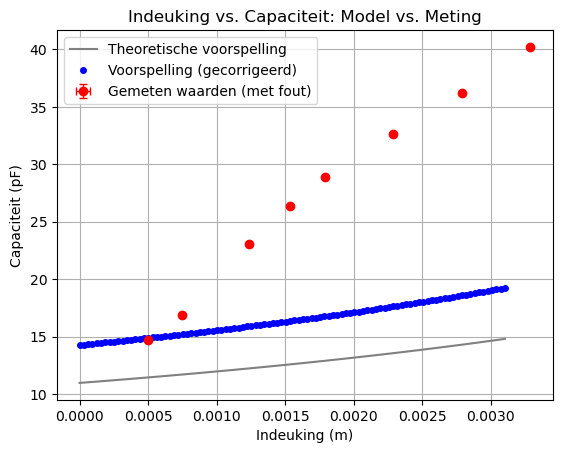

Originele voorspelling: [10.97919289 11.00795459 11.03686738 11.06593245 11.09515101]
Gecorrigeerde voorspelling: [14.27075492 14.30813938 14.34572023 14.383499   14.42147728]


In [40]:
import matplotlib.pyplot as plt

#Vraag 1: 

Idealfactor = C_sn_vierkant

Capaciteit_gecorrigeerd = Capaciteit_voorspellingpF * Idealfactor

#Vraag 2:
plt.figure

plt.errorbar(delta_x_spons, capaciteit_gemetenpF, xerr=sigma_x, yerr=sigma_C, fmt='o', color='red', ecolor='red', elinewidth=1, capsize=3, label='Gemeten waarden (met fout)')

plt.plot(delta_x_voorspelling, Capaciteit_voorspellingpF, color='gray', label='Theoretische voorspelling')

plt.plot(delta_x_voorspelling, Capaciteit_gecorrigeerd, 'bo', markersize=4, label='Voorspelling (gecorrigeerd)')  

plt.xlabel("Indeuking (m)")
plt.ylabel("Capaciteit (pF)")
plt.title("Indeuking vs. Capaciteit: Model vs. Meting")
plt.legend()
plt.grid(True)

plt.show()

print(f"Originele voorspelling: {Capaciteit_voorspellingpF[:5]}") # Toont eerste 5 waarden
print(f"Gecorrigeerde voorspelling: {Capaciteit_gecorrigeerd[:5]}")


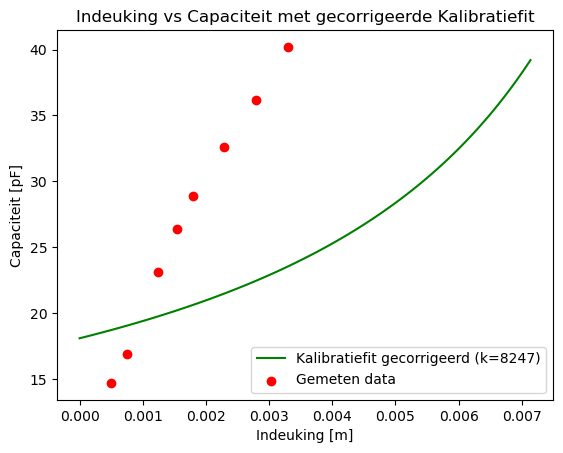

In [41]:
#Vraag 3: 
Idealfactor = C_sn_vierkant

def ontwerp_model_gecorrigeerd(m, k_fit, offset):
    delta_x = (m * 9.81) / k_fit
    d = np.maximum(0.012 - delta_x, 0.0001)
    C_theoretisch = (8.854e-12 * 1.5 * 0.01 / d) * 1e12
    return (C_theoretisch * Idealfactor) + offset

from scipy.optimize import curve_fit

popt, _ = curve_fit(ontwerp_model_gecorrigeerd, gebruikte_massa, capaciteit_gemetenpF, p0=[7000, 5])
k_echt, offset_echt = popt

massa_lijn = np.linspace(0, 6, 100) 

C_fit_gecorrigeerd = ontwerp_model_gecorrigeerd(massa_lijn, k_echt, offset_echt)

delta_x_lijn = (massa_lijn * 9.81) / k_echt

plt.plot(delta_x_lijn, C_fit_gecorrigeerd, 'g-', label=f'Kalibratiefit gecorrigeerd (k={k_echt:.0f})')
plt.plot
plt.scatter(delta_x_spons, capaciteit_gemetenpF, color='red', label='Gemeten data')
plt.xlabel("Indeuking [m]")
plt.ylabel("Capaciteit [pF]")
plt.title("Indeuking vs Capaciteit met gecorrigeerde Kalibratiefit")
plt.legend()
plt.show()



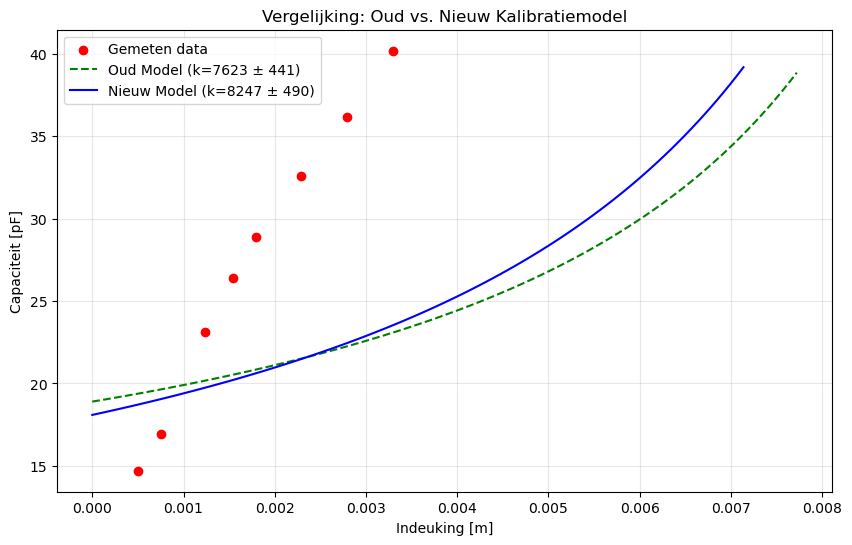

Oud model k: 7623.04
Nieuw model k: 8247.10


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. INSTELLINGEN ---
G = 9.81
Epsilon = 8.854e-12
BREEDTE = 1.5
LENGTE = 0.01
AFSTAND_0 = 0.012
FACTOR = C_sn_vierkant  # Je correctiefactor

# --- 2. DE TWEE MODELLEN ---

def model_oud(m, k, offset):
    indeuking = (m * G) / k
    d = np.maximum(AFSTAND_0 - indeuking, 0.0001)
    C_theorie = (Epsilon * BREEDTE * LENGTE / d) * 1e12
    return C_theorie + offset

def model_nieuw(m, k, offset):
    indeuking = (m * G) / k
    d = np.maximum(AFSTAND_0 - indeuking, 0.0001)
    C_theorie = (Epsilon * BREEDTE * LENGTE / d) * 1e12
    # Hier voegen we de extra factor toe:
    return (C_theorie * FACTOR) + offset


# Fit voor het oud kalibratie model
popt_oud, pcov_oud = curve_fit(model_oud, gebruikte_massa, capaciteit_gemetenpF, p0=[7000, 5])
k_oud, off_oud = popt_oud
fout_k_oud = np.sqrt(pcov_oud[0,0])

# Fit voor het nieuw kalibratie model
popt_nieuw, pcov_nieuw = curve_fit(model_nieuw, gebruikte_massa, capaciteit_gemetenpF, p0=[7000, 5])
k_nieuw, off_nieuw = popt_nieuw
fout_k_nieuw = np.sqrt(pcov_nieuw[0,0])


#Voor plotten: 

massa_lijn = np.linspace(0, 6, 100)

#capaciteit van de lijnen voor beide modellen
C_lijn_oud = model_oud(massa_lijn, k_oud, off_oud)
C_lijn_nieuw = model_nieuw(massa_lijn, k_nieuw, off_nieuw)

#indeuking
dx_oud = (massa_lijn * G) / k_oud
dx_nieuw = (massa_lijn * G) / k_nieuw

plt.figure(figsize=(10, 6))


plt.scatter(delta_x_spons, capaciteit_gemetenpF, color='red', label='Gemeten data', zorder=5)


plt.plot(dx_oud, C_lijn_oud, 'g--', label=f'Oud Model (k={k_oud:.0f} ± {fout_k_oud:.0f})')


plt.plot(dx_nieuw, C_lijn_nieuw, 'b-', label=f'Nieuw Model (k={k_nieuw:.0f} ± {fout_k_nieuw:.0f})')

plt.xlabel("Indeuking [m]")
plt.ylabel("Capaciteit [pF]")
plt.title("Vergelijking: Oud vs. Nieuw Kalibratiemodel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Oud model k: {k_oud:.2f}")
print(f"Nieuw model k: {k_nieuw:.2f}")


##### Antwoorden 6b2

We hebben onze theoretische kalibratiegrafiek vermenigvuldigd met de idealiteitsfactor, zodat het edge effect wordt meegenomen.
In de figuur vergelijken we het oude model (zonder edge effect) met het nieuwe model (met idealiteitsfactor) en de gemeten data.
Het nieuwe model ligt duidelijk dichter bij de meetpunten en beschrijft zowel de helling als de orde van grootte van de capaciteit beter.
Dit laat zien dat het meenemen van het edge effect via de idealiteitsfactor de theoretische beschrijving van de sensor significant verbetert.


#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [43]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

- Verklaarde afwijking door de idealiteitsfactor

Door de idealiteitsfactor toe te passen op onze oorspronkelijke theoretische kalibratiegrafiek verschuift de voorspelde capaciteit duidelijk richting de gemeten waarden. De afwijking tussen model en metingen neemt merkbaar af, wat betekent dat een aanzienlijk deel van het verschil verklaard kan worden door het meenemen van edge effects in de capaciteit. De idealiteitsfactor corrigeert vooral voor het feit dat het elektrische veld aan de randen uitwaaiert, waardoor de werkelijke capaciteit groter is dan de vlakke-plaatbenadering voorspelt.

- Overige oorzaken van afwijking tussen theorie en meting:

Hoewel de idealiteitsfactor een groot deel van de afwijking verklaart, blijft er een restverschil bestaan. Dit komt door meerdere elektrisch-veld- en capaciteitgerelateerde effecten die niet in het eenvoudige model zijn opgenomen:

- Capaciteiten in het circuit:

Kabels, pads en het meetinstrument voegen extra capaciteit toe in parallel met de sensor. Hierdoor meten we feitelijk C_sensor + C_extraonderdelen, terwijl het model alleen C_sensor beschrijft. 

- Niet-lineair gedrag van het diëlektricum**:

Foam heeft geen perfecte lineaire relatie tussen druk, vervorming en effectieve permittiviteit. Bij indeuking verandert de dipolenstructuur (meer aligment van het dipoolmoment met de E-veld richting), waardoor de effectieve epsilon_foam varieert.

- Mengsel van lucht en foam:

De sensor bevat altijd kleine poriën. De verhouding tussen epsilon_lucht en epsilon_foam komt niet exact overeen met de  aanname in het theoretische model, waardoor de voorspelde capaciteit systematisch afwijkt.

- Niet-uniforme indeuking over het oppervlak:

De druk wordt niet overal gelijk uitgeoefend. Omdat er geen uniform gewicht is gebruikt maar zandzakken, ontstaan lokale variaties in de afstand tussen de platen. Hierdoor is het elektrische veld niet homogeen, terwijl het model uitgaat van een perfect vlakke, gelijkmatig ingedrukte condensator.

Deze factoren samen verklaren waarom er ondanks de correctie met de idealiteitsfactor nog steeds een grote restafwijking tussen theorie en praktijk aanwezig is.